In [1]:
#Show plots inline, and load main getdist plot module and samples class
from __future__ import print_function
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))

import numpy as np
import pandas as pd
import math

import scipy
import scipy.constants as scic
from scipy.interpolate import interp1d
import scipy.interpolate as intr
from scipy.stats import norm
from scipy.optimize import curve_fit
from IPython.display import HTML

import matplotlib
matplotlib.use('Agg')

import matplotlib as mpl
from matplotlib import rc
import matplotlib.pylab as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker

from mpl_toolkits.axes_grid1 import make_axes_locatable
#from labellines import labelLine, labelLines

from classy import Class
from getdist import plots, MCSamples, loadMCSamples
#from cobaya import load_samples
#from cobaya.samplers.mcmc import plot_progress

#from uncertainties import ufloat, unumpy
#from util import *

%matplotlib inline

%config InlineBackend.figure_format = 'retina'
rc("font", weight="normal"); rc("font", size="20")
# Set the global font family to serif
mpl.rcParams['font.family'] = 'serif'
# Specify "Times New Roman" as the preferred serif font
#mpl.rcParams['font.serif'] = ['Times New Roman']

#rc("font", family='Times New Roman'); rc("font", style='italic')
rc("axes"); rc("axes",labelsize="18"); rc("xtick",labelsize="14"); rc("ytick",labelsize="14")#, labelweight="bold"
#plt.rcParams['text.usetex']=True
#plt.rcParams['text.latex.preamble'] = [r'\usepackage{sfmath} \boldmath']
font = {'family': 'Times New Roman', #'serif',#'monospace',
        'color': 'black',
        'weight': 'normal',
        'size': 16,
        'style':'italic',
        }

In [2]:
from classy import Class

In [3]:
params_cmn = {'gauge': 'newtonian',
              'nonlinear_min_k_max': 25,
              'N_ncdm': 1,
              'N_ur': 2.046,
              'non linear': 'hmcode',
              'hmcode_version': 2020,
              'output' : 'tCl,pCl,lCl,mPk',
              'l_max_scalars': 9000, 
              'lensing': 'yes',
            }

In [4]:
params_lcdm =  {'Omega_fld': 0,
                'Omega_scf': 0}
params_cmn.update(params_lcdm)

In [5]:
%%time
Model_LCDM = Class()
Model_LCDM.set(params_cmn)
Model_LCDM.compute()
BackQunt_LCDM = Model_LCDM.get_background()

CPU times: user 3min 8s, sys: 14.8 s, total: 3min 23s
Wall time: 12 s


In [6]:
Omega_exo = -0.01 
z_c_exo = 50.0
Amp_Window = 5e6
sigma_z_exo = np.sqrt(0.5 * z_c_exo**2/np.log(Amp_Window))
a_exo = Omega_exo * np.exp((z_c_exo**2)/(2.0*sigma_z_exo**2))
z_cmb = 1100 
b_exo = - a_exo #* (1+z_cmb)/z_cmb
print(a_exo, b_exo)

-50000.00000000012 50000.00000000012


In [7]:
(1+z_cmb)/z_cmb

1.000909090909091

In [8]:
density_limit = -0.2 * interp1d(BackQunt_LCDM['z'], BackQunt_LCDM['(.)rho_crit'])(z_c_exo) * 3.0/(8.0 * np.pi * scic.constants.G)
a_limit = density_limit/(1-(z_c_exo * (1 + z_cmb))/((1+z_c_exo)*z_cmb))
print(a_limit)
Omega_x_limit = a_limit * np.exp(-(z_c_exo**2)/(2.0*sigma_z_exo**2))
print(Omega_x_limit)

-40795045.891577564
-8.159009178315495


/tmp/ipykernel_260613/3613873431.py:1: DeprecationWarning: Please import `G` from the `scipy.constants` namespace; the `scipy.constants.constants` namespace is deprecated and will be removed in SciPy 2.0.0.
  density_limit = -0.2 * interp1d(BackQunt_LCDM['z'], BackQunt_LCDM['(.)rho_crit'])(z_c_exo) * 3.0/(8.0 * np.pi * scic.constants.G)


In [9]:
scic.constants.G

/tmp/ipykernel_260613/2590683580.py:1: DeprecationWarning: Please import `G` from the `scipy.constants` namespace; the `scipy.constants.constants` namespace is deprecated and will be removed in SciPy 2.0.0.
  scic.constants.G


6.6743e-11

In [10]:
params_exo =  {'Omega_fld': 0,
                'Omega_scf': 0,
                'a_exo': a_exo, 
                'b_exo': b_exo,
                'z_c_exo': z_c_exo,
                'sigma_z_exo': sigma_z_exo, 
              }
params_cmn.update(params_exo)

In [11]:
%%time
Model = Class()
Model.set(params_cmn)
Model.compute()
BackQunt = Model.get_background()

CPU times: user 3min 8s, sys: 12.5 s, total: 3min 21s
Wall time: 11.9 s


/tmp/ipykernel_260613/4012052106.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=18)


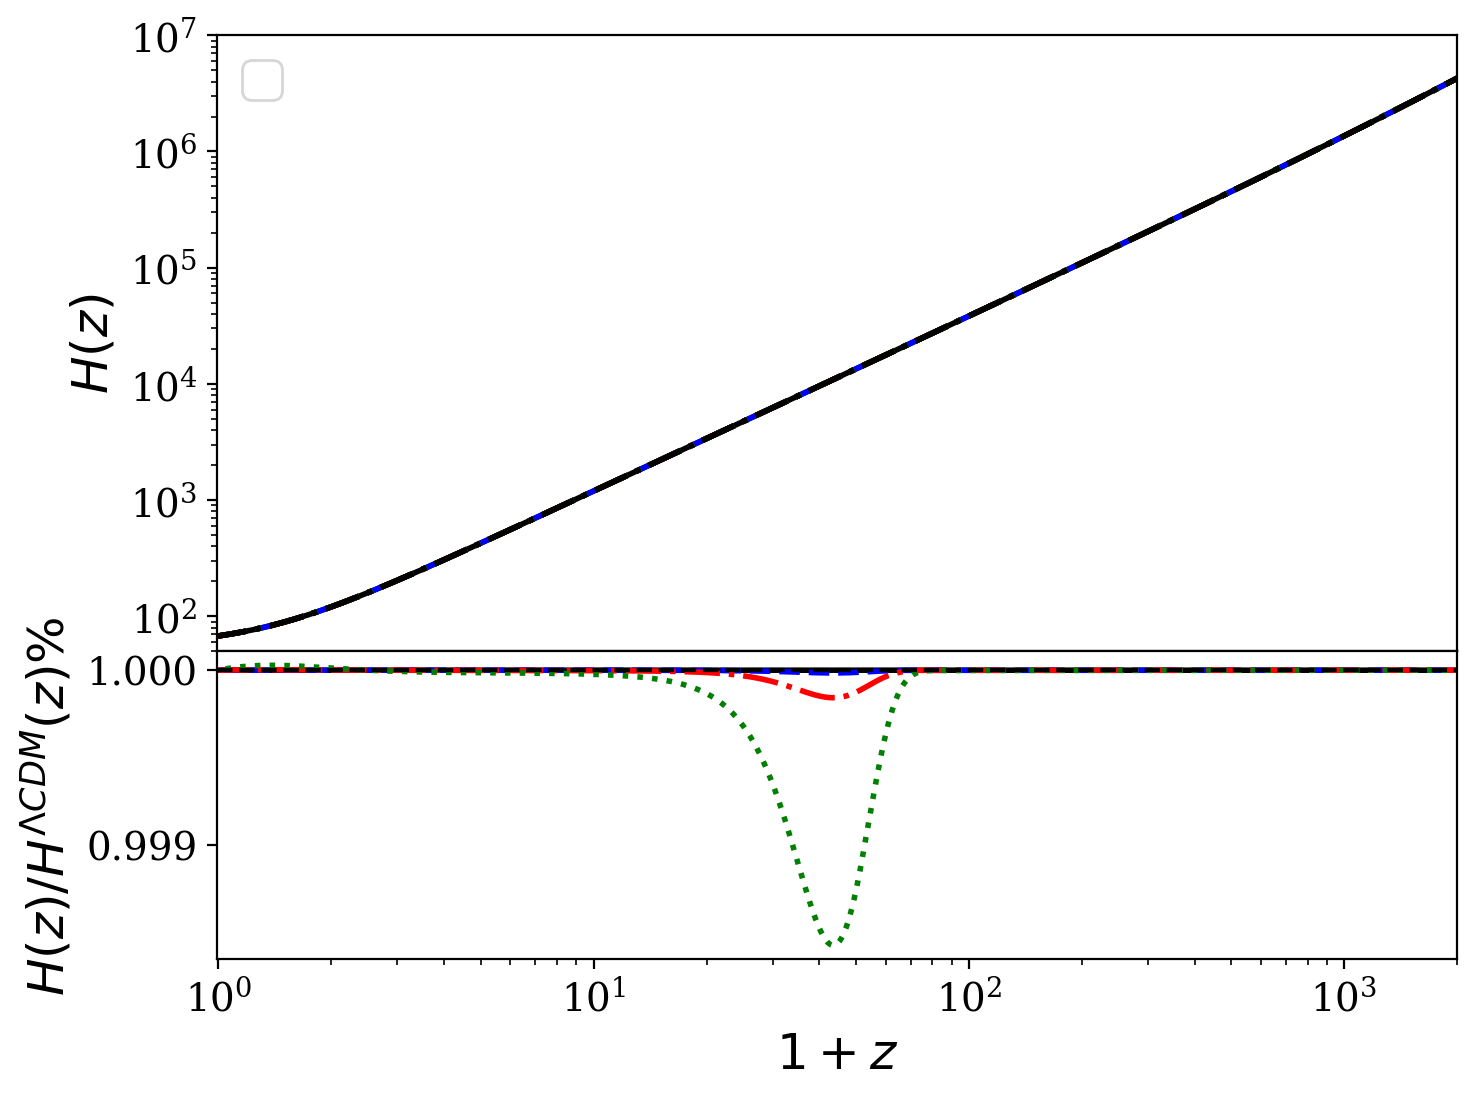

In [12]:
fig, (ax1,ax2) = plt.subplots(2,1, figsize=(8,6), sharex=True, height_ratios=(2,1))
plt.subplots_adjust(hspace=0.0)
lstyls = ['-', '--', '-.', ':']
colors = ['k', 'b', 'r', 'g']
Omega_exo_arr = -np.array([0.0, 1e-5, 1e-4, 1e-3])
a_exo_arr = Omega_exo_arr * np.exp((z_c_exo**2)/(2.0*sigma_z_exo**2))
for i,a in enumerate(a_exo_arr):
    params_exo.update({'a_exo' : a})
    b_exo = - a #* (1+z_cmb)/z_cmb
    params_exo.update({'b_exo' : b_exo})
    params_cmn.update(params_exo)
    Model.set(params_cmn)
    Model.compute()
    BackQunt = Model.get_background()
    ax1.plot(1+ BackQunt['z'], 1e-3*scic.c*BackQunt['H [1/Mpc]'], ls=lstyls[i], lw=2., c=colors[i])
    ax1.plot(1+ BackQunt_LCDM['z'], 1e-3*scic.c*BackQunt_LCDM['H [1/Mpc]'], ls='-.', lw=2., c='k')
    ax2.plot(1+ BackQunt['z'], 1e-3*scic.c*BackQunt['H [1/Mpc]']/(1e-3*scic.c*BackQunt_LCDM['H [1/Mpc]']), ls=lstyls[i], lw=2., c=colors[i])
ax2.axhline(1.0, ls='--', lw=1.5, c='k')
#ax2.axvline(16.0, ls='--', c='k', lw=1.5)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend(fontsize=18)
ax2.set_xlabel(r'$1 + z$', fontsize=18)
ax1.set_ylabel(r'$H(z)$', fontsize=18)
ax2.set_ylabel(r'$H(z)/H^{\Lambda CDM}(z) \%$', fontsize=18)
ax1.set_xlim(0.99, 2e3)
ax1.set_ylim(5e1, 1e7)
#plt.savefig(savedir + '%s_Hubble.pdf'%RUNs_Dict[2][0].split(':')[0], bbox_inches='tight')
plt.show()

/tmp/ipykernel_260613/2094177203.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=18)


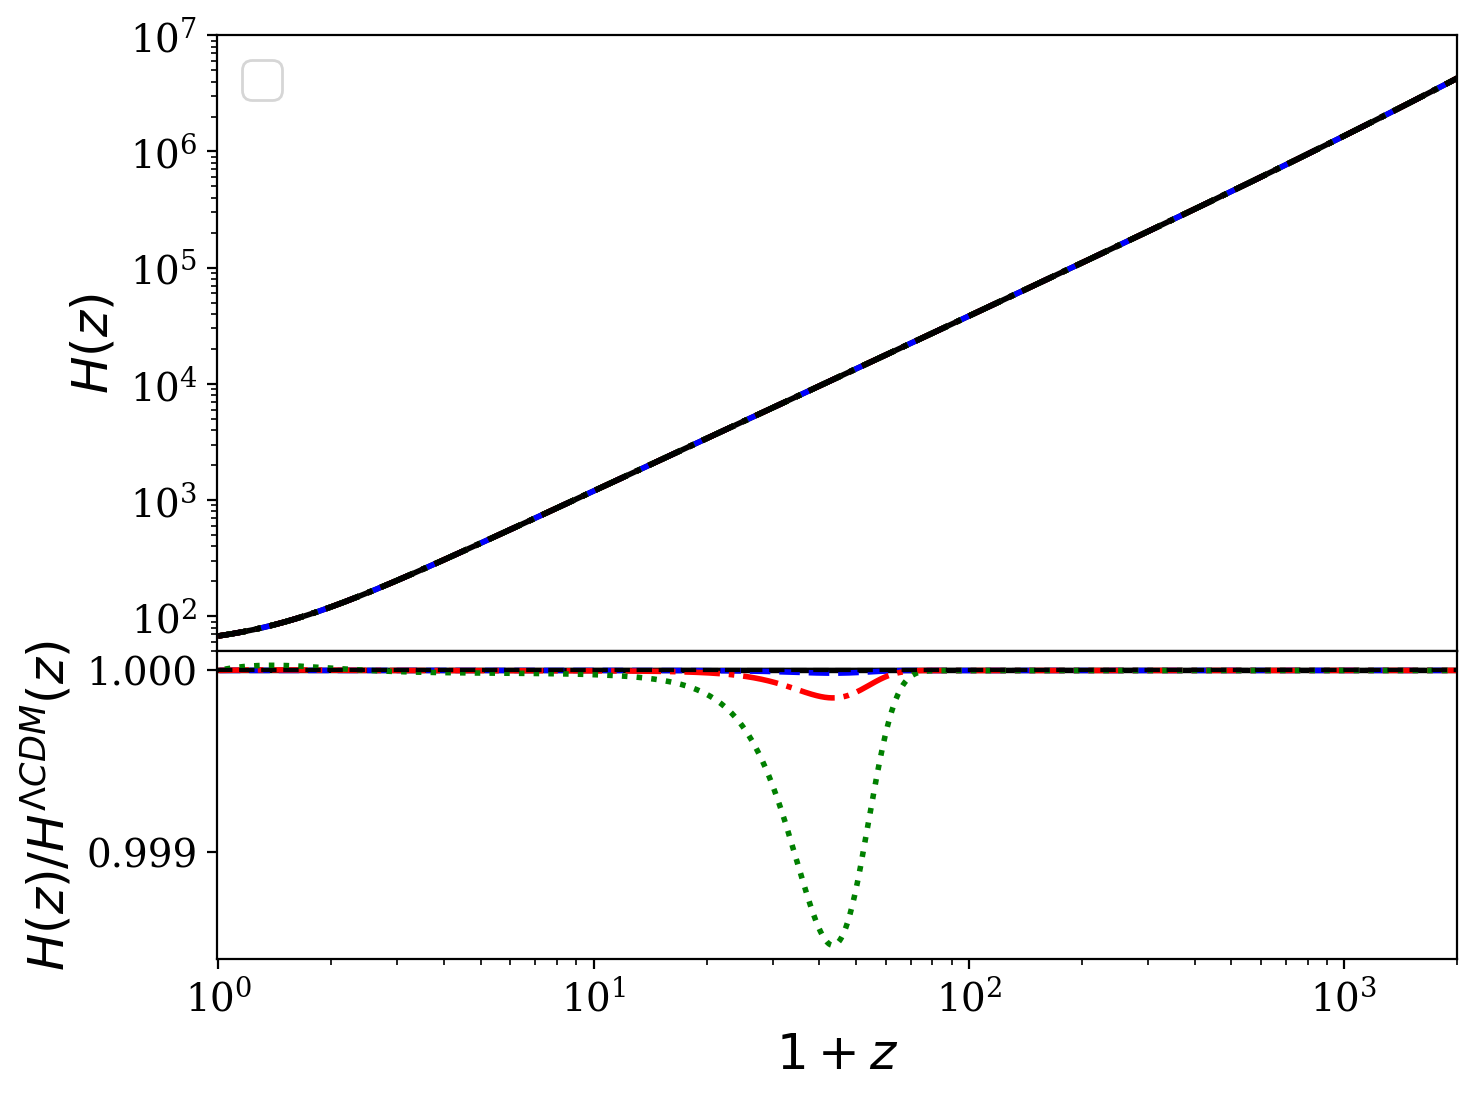

In [13]:
fig, (ax1,ax2) = plt.subplots(2,1, figsize=(8,6), sharex=True, height_ratios=(2,1))
plt.subplots_adjust(hspace=0.0)
lstyls = ['-', '--', '-.', ':']
colors = ['k', 'b', 'r', 'g']
Omega_exo_arr = -np.array([0.0, 1e-5, 1e-4, 1e-3])
a_exo_arr = Omega_exo_arr * np.exp((z_c_exo**2)/(2.0*sigma_z_exo**2))
for i,a in enumerate(a_exo_arr):
    params_exo.update({'a_exo' : a})
    b_exo = - a * (1+z_cmb)/z_cmb
    params_exo.update({'b_exo' : b_exo})
    params_cmn.update(params_exo)
    Model.set(params_cmn)
    Model.compute()
    BackQunt = Model.get_background()
    ax1.plot(1+ BackQunt['z'], 1e-3*scic.c*BackQunt['H [1/Mpc]'], ls=lstyls[i], lw=2., c=colors[i])
    ax1.plot(1+ BackQunt_LCDM['z'], 1e-3*scic.c*BackQunt_LCDM['H [1/Mpc]'], ls='-.', lw=2., c='k')
    ax2.plot(1+ BackQunt['z'], 1e-3*scic.c*BackQunt['H [1/Mpc]']/(1e-3*scic.c*BackQunt_LCDM['H [1/Mpc]']), ls=lstyls[i], lw=2., c=colors[i])
ax2.axhline(1.0, ls='--', lw=1.5, c='k')
#ax2.axvline(16.0, ls='--', c='k', lw=1.5)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend(fontsize=18)
ax2.set_xlabel(r'$1 + z$', fontsize=18)
ax1.set_ylabel(r'$H(z)$', fontsize=18)
ax2.set_ylabel(r'$H(z)/H^{\Lambda CDM}(z)$', fontsize=18)
ax1.set_xlim(0.99, 2e3)
ax1.set_ylim(5e1, 1e7)
#plt.savefig(savedir + '%s_Hubble.pdf'%RUNs_Dict[2][0].split(':')[0], bbox_inches='tight')
plt.show()

/tmp/ipykernel_260613/1355846692.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=18)


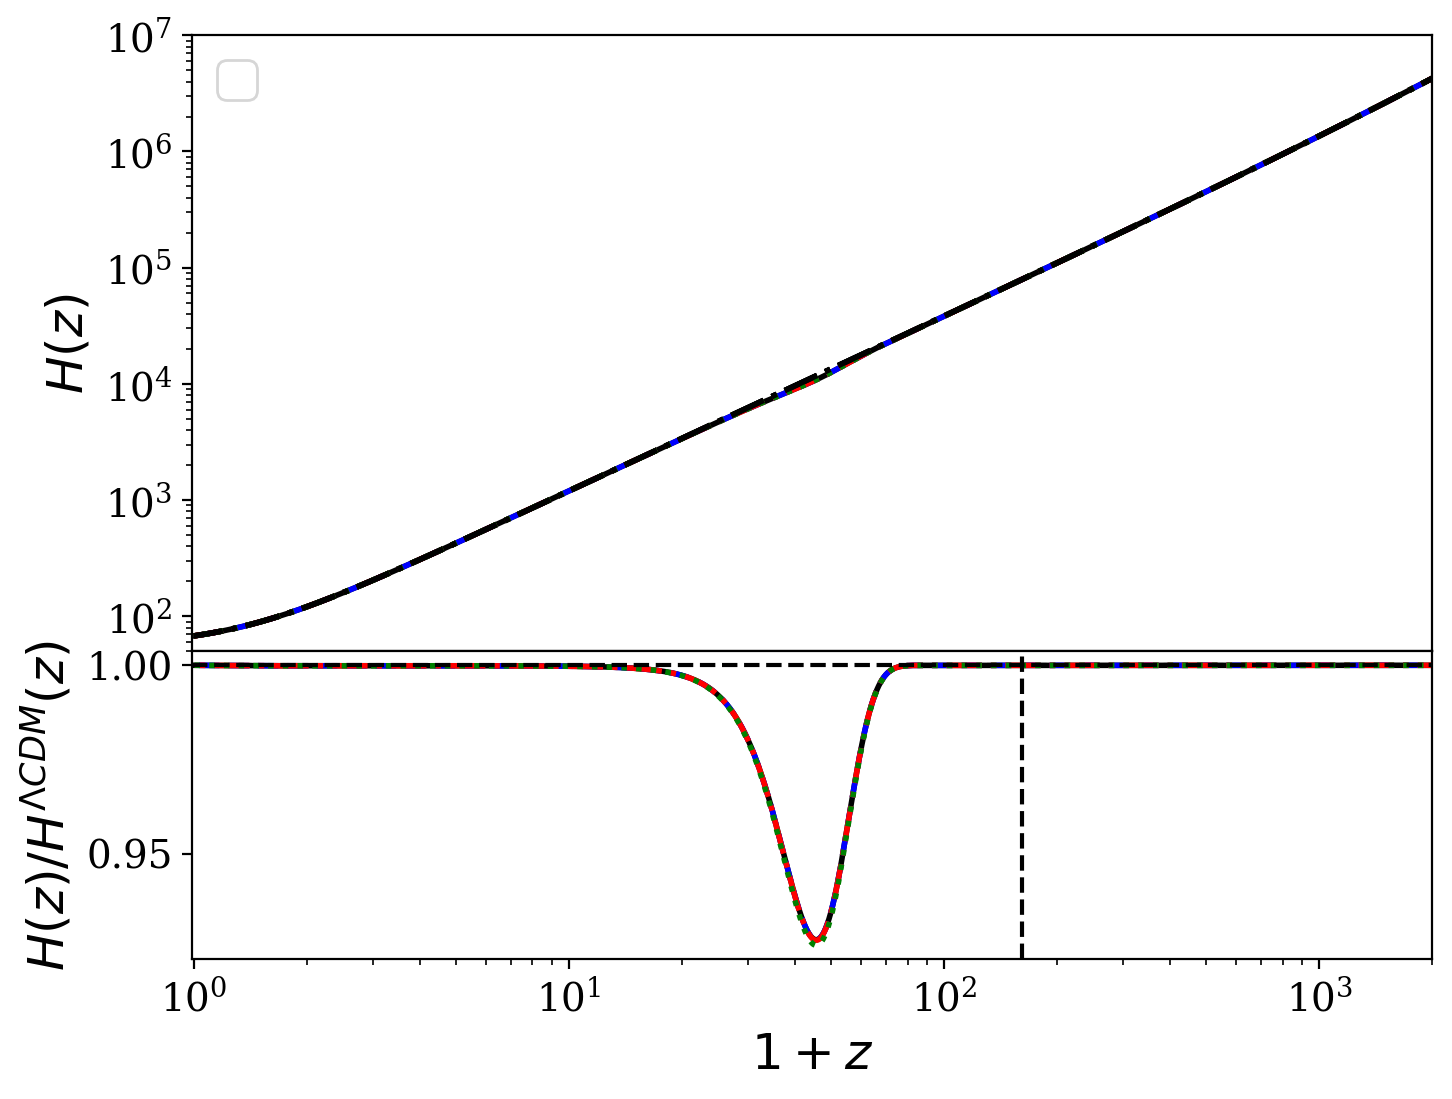

In [14]:
fig, (ax1,ax2) = plt.subplots(2,1, figsize=(8,6), sharex=True, height_ratios=(2,1))
plt.subplots_adjust(hspace=0.0)
lstyls = ['-', '--', '-.', ':']
colors = ['k', 'b', 'r', 'g']
barr = -1 * np.array([0.1, 1.0, 10.0, 100.0 ])
Omega_exo_arr = np.array([0.0, 0.01, 0.001, 0.0001])
a_exo_arr = Omega_exo_arr * np.exp((z_c_exo**2)/(2.0*sigma_z_exo**2))
for i,b in enumerate(barr):
    params_exo.update({'b_exo' : b})
    params_cmn.update(params_exo)
    Model.set(params_cmn)
    Model.compute()
    BackQunt = Model.get_background()
    ax1.plot(1+ BackQunt['z'], 1e-3*scic.c*BackQunt['H [1/Mpc]'], ls=lstyls[i], lw=2., c=colors[i])
    ax1.plot(1+ BackQunt_LCDM['z'], 1e-3*scic.c*BackQunt_LCDM['H [1/Mpc]'], ls='-.', lw=2., c='k')
    ax2.plot(1+ BackQunt['z'], 1e-3*scic.c*BackQunt['H [1/Mpc]']/(1e-3*scic.c*BackQunt_LCDM['H [1/Mpc]']), ls=lstyls[i], lw=2., c=colors[i])
ax2.axhline(1.0, ls='--', lw=1.5, c='k')
ax2.axvline(160+1, ls='--', c='k', lw=1.5)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend(fontsize=18)
ax2.set_xlabel(r'$1 + z$', fontsize=18)
ax1.set_ylabel(r'$H(z)$', fontsize=18)
ax2.set_ylabel(r'$H(z)/H^{\Lambda CDM}(z)$', fontsize=18)
ax1.set_xlim(0.99, 2e3)
ax1.set_ylim(5e1, 1e7)
#plt.savefig(savedir + '%s_Hubble.pdf'%RUNs_Dict[2][0].split(':')[0], bbox_inches='tight')
plt.show()

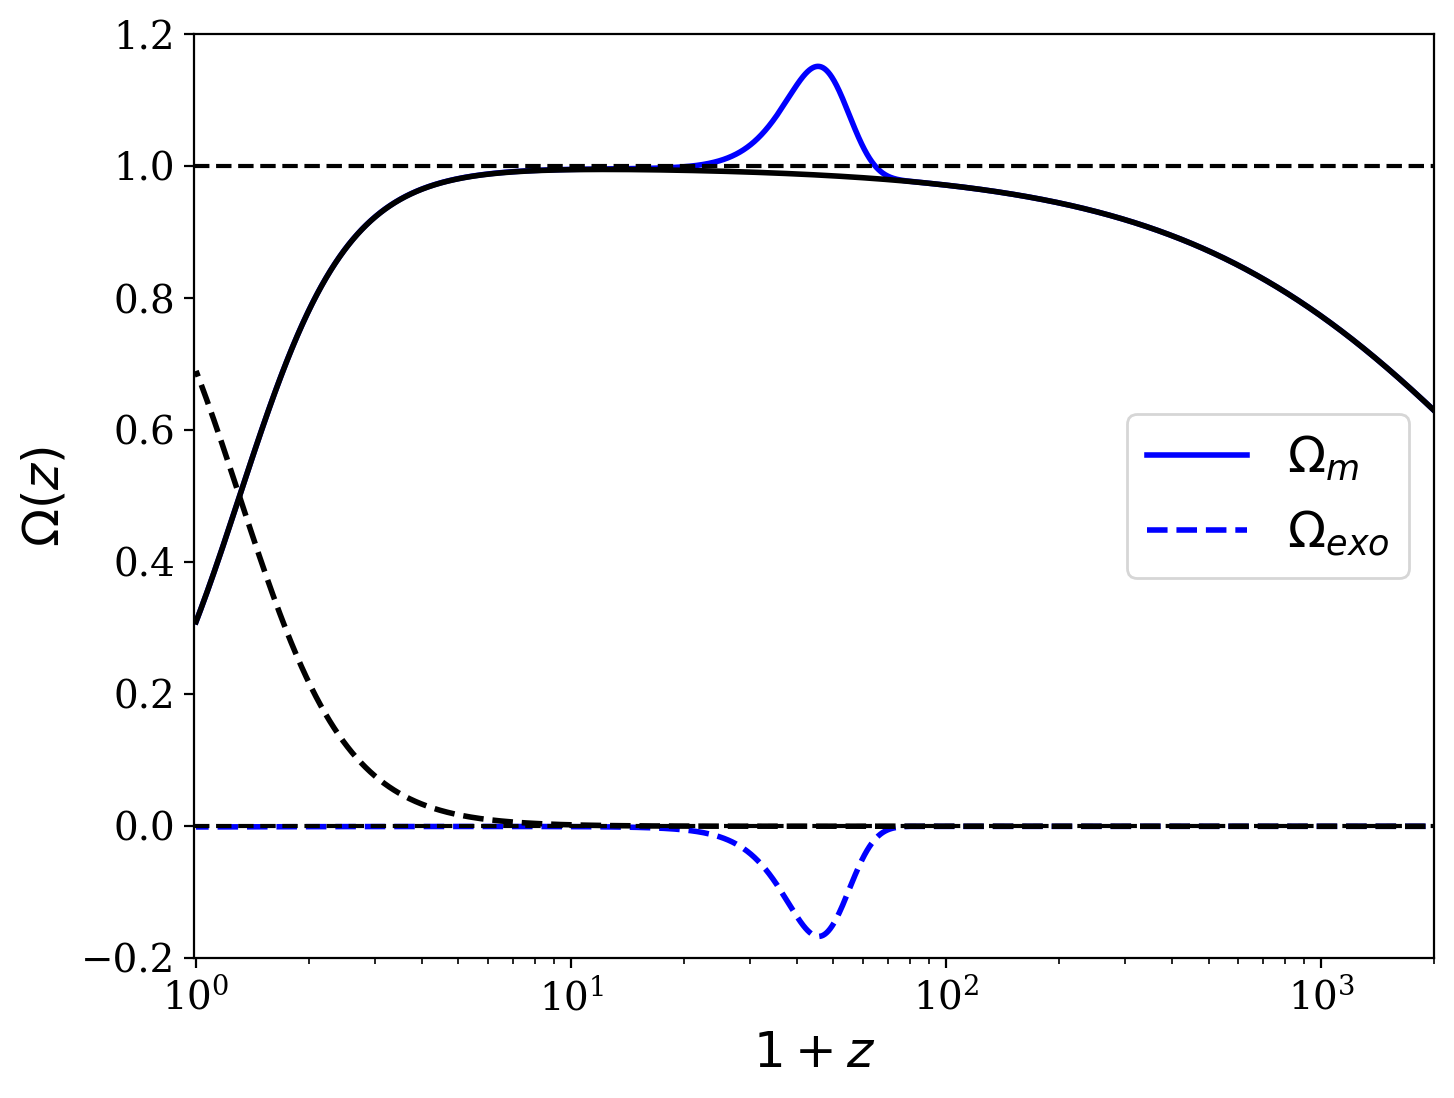

In [15]:
fig, ax1 = plt.subplots(1,1, figsize=(8,6), sharex=True)#, height_ratios=(2,1))
plt.subplots_adjust(hspace=0.0)
ax1.plot(1+ BackQunt['z'], BackQunt['(.)rho_cdm']/BackQunt['(.)rho_crit'] + BackQunt['(.)rho_b']/BackQunt['(.)rho_crit'] , ls='-', lw=2., c='b', label=r'$\Omega_{m}$')
ax1.plot(1+ BackQunt['z'], BackQunt['(.)rho_exo']/BackQunt['(.)rho_crit'], ls='--', lw=2., c='b', label=r'$\Omega_{exo}$')

ax1.plot(1+ BackQunt_LCDM['z'], BackQunt_LCDM['(.)rho_cdm']/BackQunt_LCDM['(.)rho_crit'] + BackQunt_LCDM['(.)rho_b']/BackQunt_LCDM['(.)rho_crit'], ls='-', lw=2., c='k')
ax1.plot(1+ BackQunt_LCDM['z'], BackQunt_LCDM['(.)rho_lambda']/BackQunt_LCDM['(.)rho_crit'], ls='--', lw=2., c='k')
ax1.legend(fontsize=18)  
ax1.axhline(0.0, ls='--', lw=1.5, c='k')
ax1.axhline(1.0, ls='--', lw=1.5, c='k')
ax1.set_xscale('log')
#ax1.set_yscale('log')
ax1.set_xlabel(r'$1 + z$', fontsize=18)
ax1.set_ylabel(r'$\Omega(z)$', fontsize=18)
#ax2.set_ylabel(r'$H(z)/H^{\Lambda CDM}(z)$', fontsize=18)
ax1.set_xlim(0.99, 2e3)
ax1.set_ylim(-0.2, 1.2)
#ax1.set_ylim(0., 1.)
#plt.savefig(savedir + '%s_Omega.pdf'%RUNs_Dict[2][0].split(':')[0], bbox_inches='tight')
plt.show()

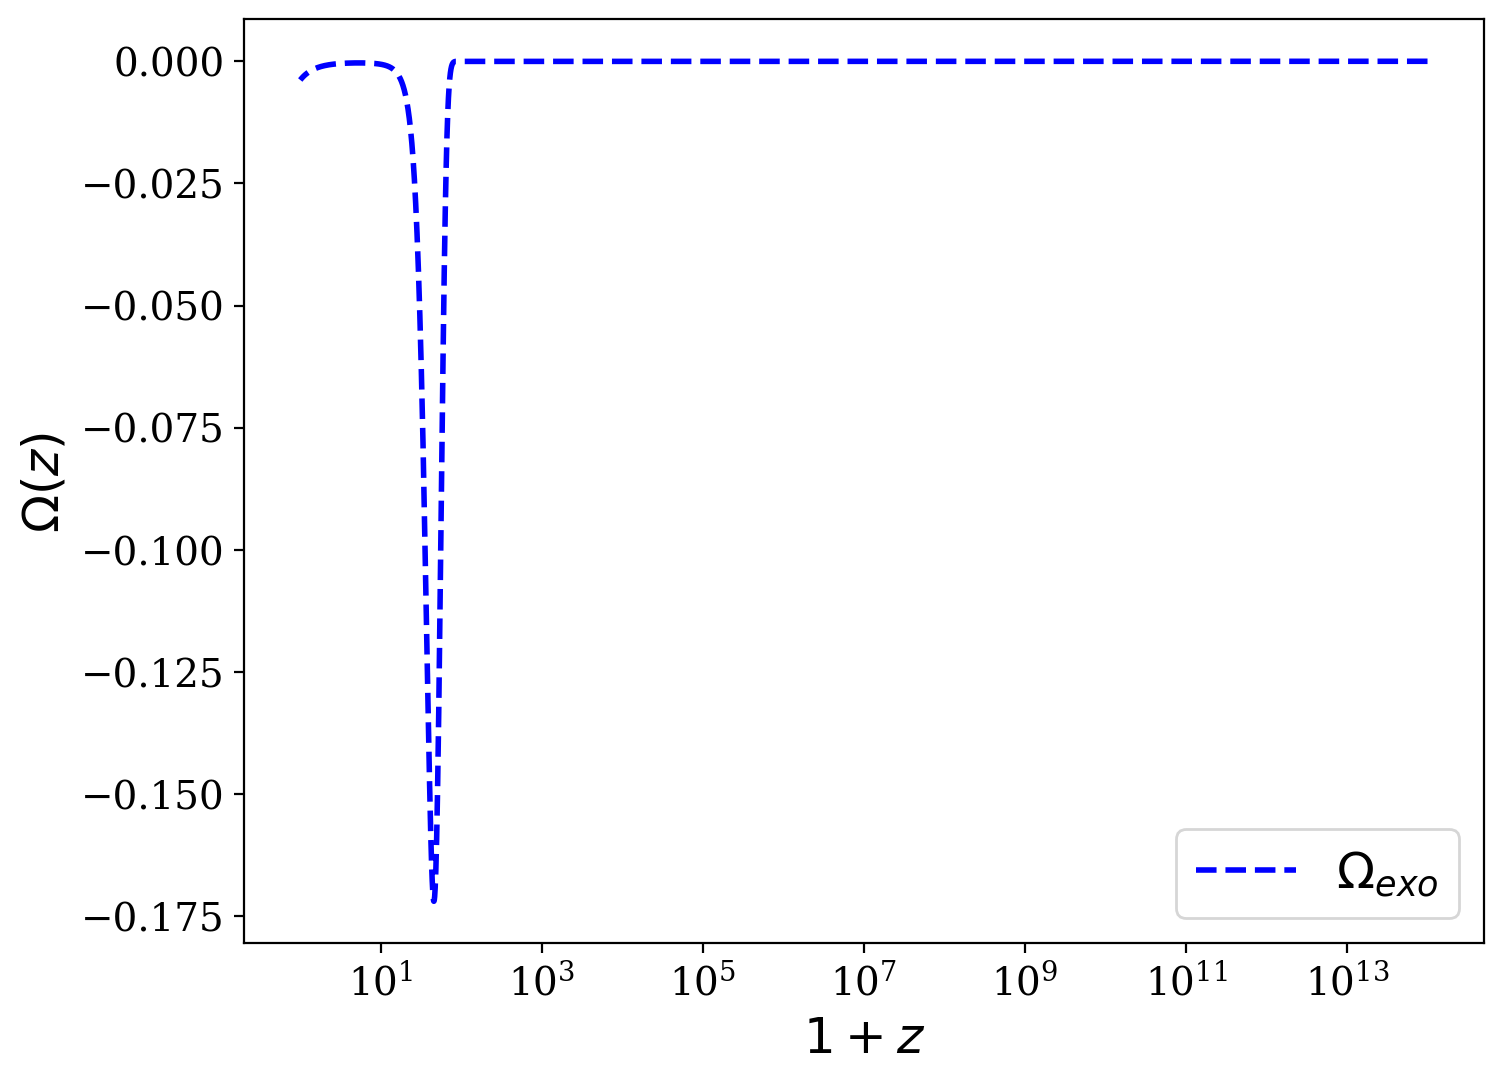

In [16]:
fig, ax1 = plt.subplots(1,1, figsize=(8,6), sharex=True)#, height_ratios=(2,1))
plt.subplots_adjust(hspace=0.0)
ax1.plot(1+ BackQunt['z'], BackQunt['(.)rho_exo']/BackQunt_LCDM['(.)rho_cdm'], ls='--', lw=2., c='b', label=r'$\Omega_{exo}$')

ax1.legend(fontsize=18)  
#ax1.axhline(0.0, ls='--', lw=1.5, c='k')
#ax1.axhline(1.0, ls='--', lw=1.5, c='k')
ax1.set_xscale('log')
#ax1.set_yscale('log')
ax1.set_xlabel(r'$1 + z$', fontsize=18)
ax1.set_ylabel(r'$\Omega(z)$', fontsize=18)
#ax2.set_ylabel(r'$H(z)/H^{\Lambda CDM}(z)$', fontsize=18)
# ax1.set_xlim(0.99, 2e3)
# ax1.set_ylim(-0.2, 1.2)
#ax1.set_ylim(0., 1.)
#plt.savefig(savedir + '%s_Omega.pdf'%RUNs_Dict[2][0].split(':')[0], bbox_inches='tight')
plt.show()

In [17]:
def rho_x(z, a, b, z_c, sgm):
    return (a + b * z/(1 + z)) * np.exp(-(z-z_c)**2/(2 * sgm**2))
def rho_x_nogauss(z, a, b):
    return a + b * z/(1 + z)

In [18]:
zthr = plt.linspace(0,1e3, 10000)

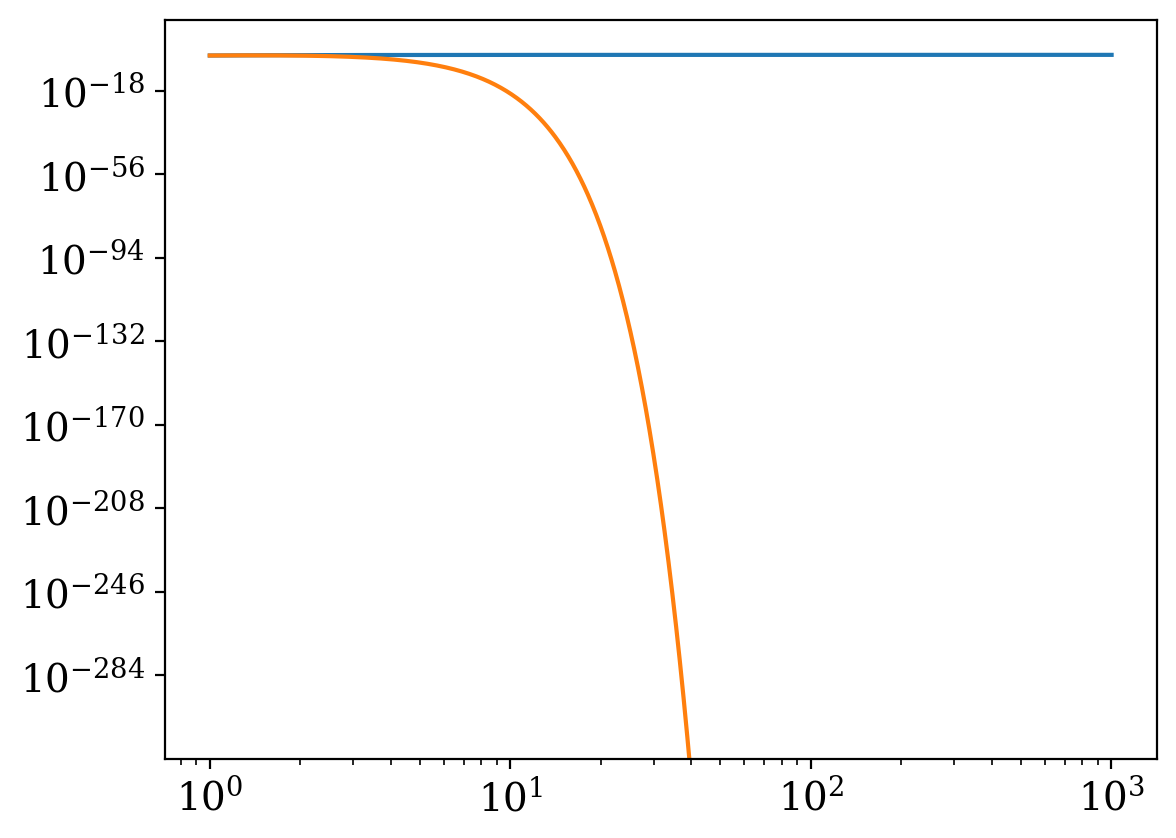

In [19]:
#plt.loglog(1+zthr, rho_x(zthr, 0.01, 0.1, 10, 3))
plt.loglog(1+zthr, rho_x_nogauss(zthr, 1e-2, 1e-2))
plt.loglog(1+zthr, rho_x(zthr, 1e-2, 1e-2, 0.0, 1.0))

(0.0, 20.0)

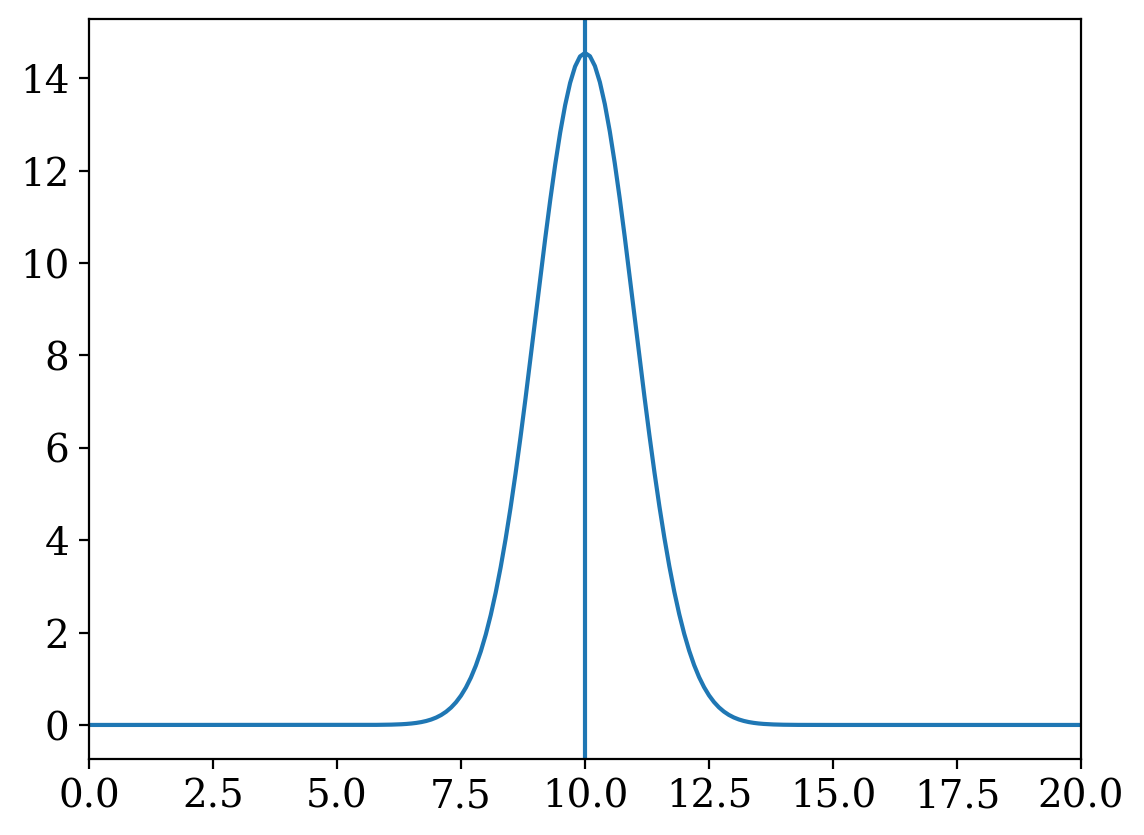

In [20]:
plt.plot(zthr, (10 + 5 * zthr/(1+zthr)) * np.exp(-0.5 * (zthr-10.0)**2/(1**2)))
plt.axvline(10.0)
plt.xlim(0., 20)

In [21]:
def rho_x(z,z_c, sgm):
    return np.exp(-(z-z_c)**2/(2 * sgm**2))

(0.0, 20.0)

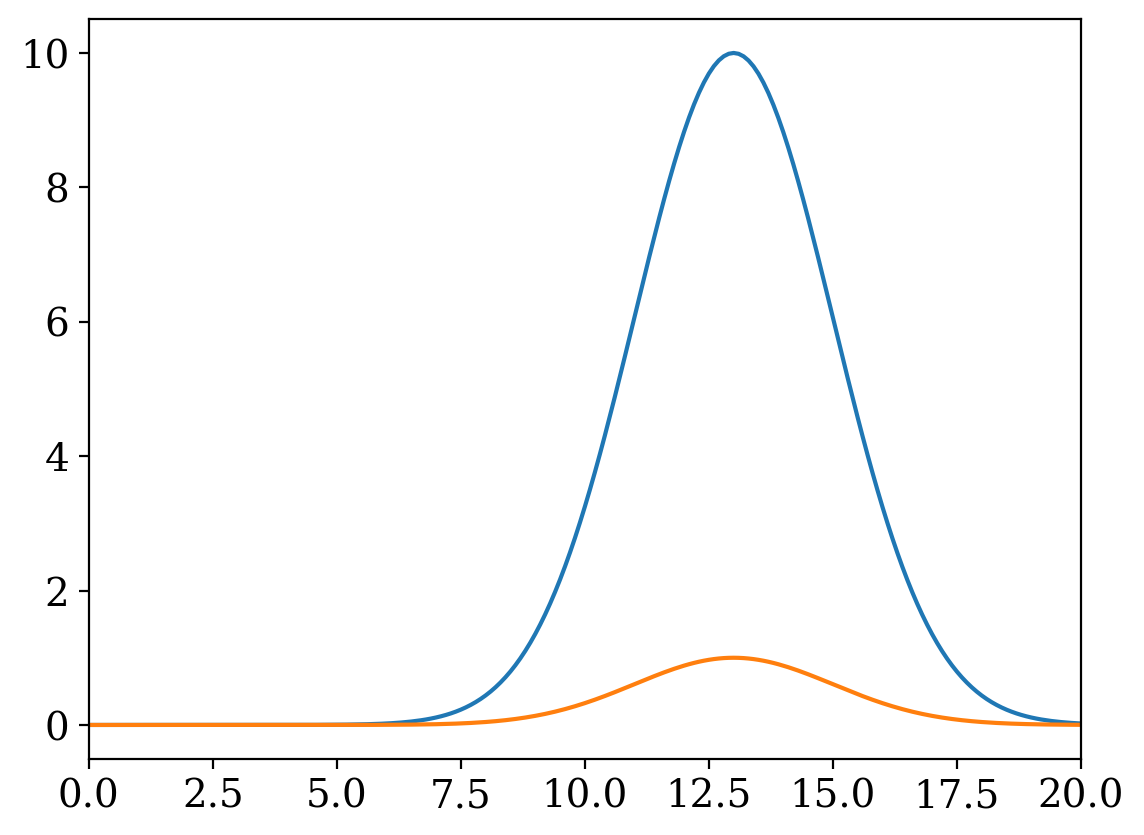

In [22]:
plt.plot(zthr, 10 * rho_x(zthr,13., 2.0))
plt.plot(zthr, 1 * rho_x(zthr,13., 2.0))
plt.xlim(0.0, 20.0)

## Example of classy

In [23]:
from classy import Class

In [24]:
Model_LCDM  = Class()

In [25]:
parm = {'H0':70.0, 'Omega_cdm':0.3}
Model_LCDM.set(parm)
Model_LCDM.compute()

In [26]:
Model_LCDM.luminosity_distance

<bound method Class.luminosity_distance of <classy._classy.Class object at 0xa65a350>>

/tmp/ipykernel_260613/2351554186.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(1+z, 5.0*np.log10(Model_LCDM.luminosity_distance(z)) + 25)


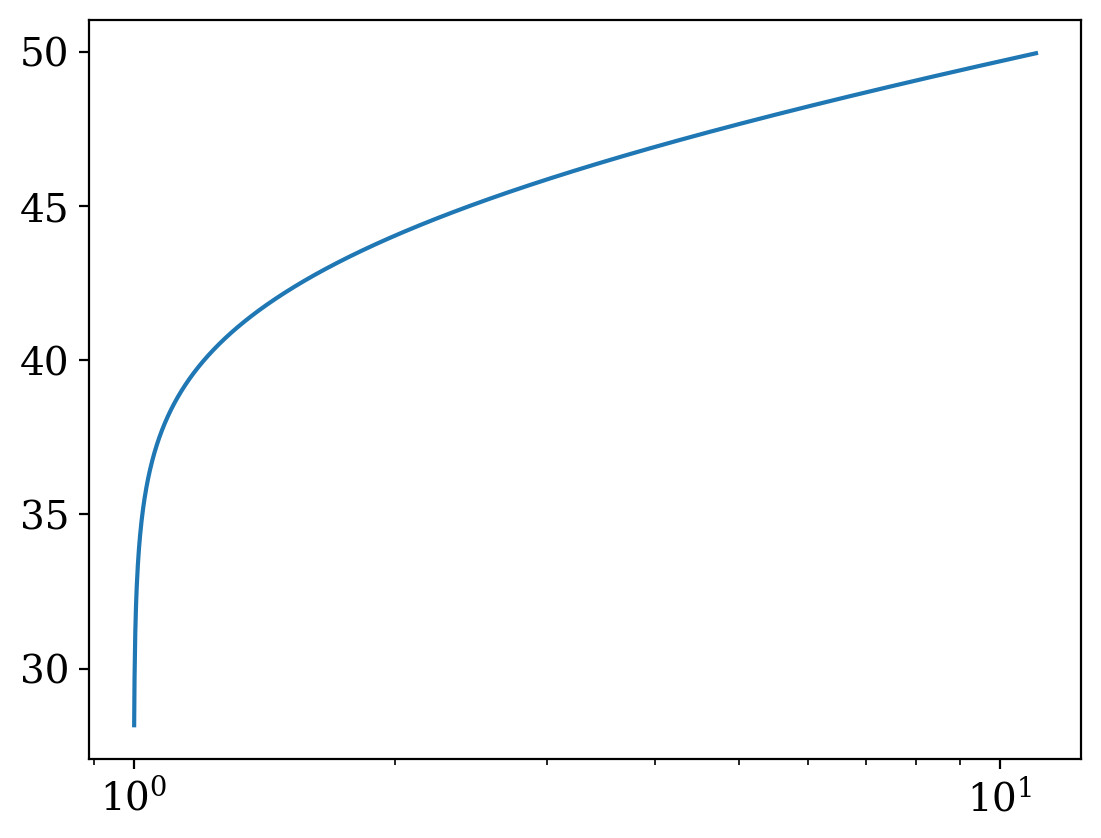

In [27]:
import scipy.constants as sc
z = np.linspace(0, 1e1, 10000)
plt.figure()
plt.semilogx(1+z, 5.0*np.log10(Model_LCDM.luminosity_distance(z)) + 25)
plt.show()